In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#### Breakdown of the imported modules and their uses:

*   **`torch`**: This is the main PyTorch library. It provides core functionalities for tensor operations, automatic differentiation, and defines the basic building blocks for neural networks.

*   **`torch.nn`**: This module contains all the necessary components to build neural networks. It includes predefined layers (like convolutional layers, linear layers), activation functions, and loss functions.

*   **`torch.optim`**: This package implements various optimization algorithms (e.g., SGD, Adam, RMSprop) that are used to update the weights of a neural network during training to minimize the loss function.

*   **`torchvision.datasets`**: This module provides access to popular datasets (like MNIST, CIFAR-10) and tools to download and prepare them for use with PyTorch models.

*   **`torchvision.transforms`**: This module contains common image transformations (e.g., resizing, cropping, normalization, data augmentation) that are often used to preprocess image data before feeding it into a neural network.

*   **`torch.utils.data.DataLoader`**: This utility is used to efficiently load and batch data during the training and evaluation of machine learning models. It handles shuffling, batching, and multiprocessing for data loading.

In [2]:
# Transform images to tensors and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


*   **`transform = transforms.Compose([...])`**: This creates a sequence of transformations. `transforms.Compose` is a utility class that allows you to chain multiple image transformations together. The transformations within the list will be applied in the order they are specified.

*   **`transforms.ToTensor()`**: This transformation converts a PIL Image or NumPy `ndarray` (H x W x C) in the range \[0, 255\] to a PyTorch `FloatTensor` of shape (C x H x W) in the range \[0.0, 1.0\]. This is necessary because PyTorch models expect input in the form of tensors.

*   **`transforms.Normalize((0.5,), (0.5,))`**: This transformation normalizes a tensor image with mean and standard deviation. The arguments are `(mean,)` and `(std,)` for a single-channel image (like grayscale MNIST images). In this case, it's normalizing the pixel values from the \[0.0, 1.0\] range to \[(-1.0), 1.0\] using the formula `output = (input - mean) / std`. This helps in stabilizing and accelerating the training process of neural networks.

'CHW' format refers to the order of dimensions for image tensors in PyTorch.

*   **C: Channels** (e.g., 1 for grayscale images, 3 for RGB images).
*   **H: Height** (the number of pixels vertically).
*   **W: Width** (the number of pixels horizontally).

When `transforms.ToTensor()` is applied, it converts an image into a PyTorch tensor. While many image processing libraries (like OpenCV or PIL) often use a 'HWC' (Height x Width x Channels) order for images, PyTorch (and other deep learning frameworks like TensorFlow/Keras, especially older versions) prefers the 'CHW' format for its convolutional layers. This order is more efficient for how convolutions are implemented in these frameworks.

In [3]:
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.78MB/s]


*   **`train_data = datasets.MNIST(...)`**: This line creates an instance of the MNIST dataset for training.
*   **`test_data = datasets.MNIST(...)`**: This line creates an instance of the MNIST dataset for testing.

Both calls to `datasets.MNIST` share common parameters:

*   **`root='./data'`**: This specifies the directory where the MNIST dataset files will be stored. If the directory doesn't exist, `download=True` will create it.
*   **`train=True`** (for `train_data`): This indicates that you want the training split of the dataset (typically 60,000 images).
*   **`train=False`** (for `test_data`): This indicates that you want the test split of the dataset (typically 10,000 images).
*   **`download=True`**: If the dataset is not found at the specified `root` path, it will be downloaded from the internet.
*   **`transform=transform`**: This applies the `transform` object (defined in the previous cell) to each image loaded from the dataset. This ensures that the images are converted to PyTorch tensors and normalized before being used by the model.

In [4]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))

Training samples: 60000
Test samples: 10000


Batch shape: torch.Size([64, 1, 28, 28])


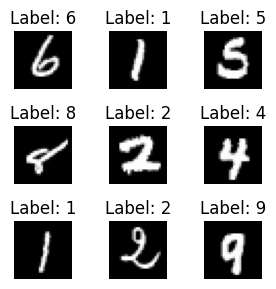

In [7]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)

# Show first 9 images
fig, axes = plt.subplots(3, 3, figsize=(3,3))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [25]:
class MNISTnet(nn.Module):
  def __init__(self):
    super(MNISTnet, self).__init__()
    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self,x):
      return self.network(x)

model = MNISTnet()
print(model)

MNISTnet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


*   **`class MNISTnet(nn.Module):`**: This defines a class `MNISTnet` that inherits from `nn.Module`, which is the base class for all neural network modules in PyTorch.

*   **`def __init__(self):`**: The constructor sets up the layers of the neural network.
    *   `super(MNISTnet, self).__init__()`: Calls the constructor of the parent `nn.Module` class.
    *   `self.network = nn.Sequential(...)`: This defines the sequential layers of the network:
        *   **`nn.Flatten()`**: Converts the 2D image input (28x28) into a 1D vector (784 features) for the linear layers.
        *   **`nn.Linear(28*28, 128)`**: A fully connected layer that takes 784 input features and outputs 128 features.
        *   **`nn.ReLU()`**: The Rectified Linear Unit activation function, which introduces non-linearity.
        *   **`nn.Linear(128, 64)`**: Another fully connected layer from 128 to 64 features.
        *   **`nn.ReLU()`**: Another ReLU activation.
        *   **`nn.Linear(64, 10)`**: The final fully connected layer that outputs 10 features, corresponding to the 10 possible digit classes (0-9).

*   **`def forward(self, x):`**: This method defines the forward pass of the network, specifying how input `x` flows through the defined `self.network`.

*   **`model = MNISTnet()`**: This creates an instance of your `MNISTnet` class.

*   **`print(model)`**: This prints a summary of the model's architecture, showing the layers and their parameters.

In [27]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

*   **`criterion = nn.CrossEntropyLoss()`**: This defines the **loss function**. `nn.CrossEntropyLoss` is commonly used for multi-class classification problems like MNIST. It measures the difference between the network's predicted output (logits) and the true labels. The goal of training is to minimize this loss.

*   **`optimizer = optim.Adam(model.parameters(), lr=0.001)`**: This defines the **optimizer**. The optimizer is responsible for updating the model's weights (`model.parameters()`) based on the calculated gradients of the loss function. `optim.Adam` is a popular and effective optimization algorithm. `lr=0.001` sets the **learning rate**, which controls how large a step the optimizer takes when adjusting the weights.

In [28]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f} — Accuracy: {accuracy:.2f}%")

Epoch 1/5 — Loss: 0.3882 — Accuracy: 88.14%
Epoch 2/5 — Loss: 0.1701 — Accuracy: 94.78%
Epoch 3/5 — Loss: 0.1227 — Accuracy: 96.20%
Epoch 4/5 — Loss: 0.1000 — Accuracy: 96.91%
Epoch 5/5 — Loss: 0.0832 — Accuracy: 97.36%


It implements the training process for your `MNISTnet` model. It iterates over the training data multiple times (epochs), adjusts the model's weights, and tracks performance metrics.

Here's a detailed explanation:

*   **`epochs = 5`**: This line sets the number of training epochs. An epoch is one complete pass through the entire training dataset. Training for multiple epochs allows the model to learn from the data iteratively and improve its performance.

*   **`for epoch in range(epochs):`**: This is the outer loop that controls the number of epochs the model will train for. The code inside this loop will be executed `epochs` (5 in this case) times.

*   **`total_loss = 0`, `correct = 0`, `total = 0`**: These lines initialize variables at the beginning of each epoch to accumulate performance metrics (loss, correct predictions, and total samples) over all batches within that epoch.

*   **`for images, labels in train_loader:`**: This is the inner loop that iterates over the `train_loader`. As discussed earlier, `train_loader` yields batches of images and their corresponding labels. In each iteration of this inner loop, `images` will contain 64 image tensors and `labels` will contain 64 label tensors.

    *   **`outputs = model(images)` (Forward Pass)**:
        *   This is where the input `images` are fed through your `MNISTnet` model.
        *   The `model.__call__(images)` implicitly calls the `forward` method you defined in your `MNISTnet` class.
        *   `outputs` will contain the raw predictions (logits) from the final linear layer of your network for each image in the batch.

    *   **`loss = criterion(outputs, labels)` (Calculate Loss)**:
        *   The `criterion` (which is `nn.CrossEntropyLoss`) takes the model's `outputs` (predictions) and the true `labels` for the current batch.
        *   It calculates how far off the model's predictions are from the actual labels. The goal is to minimize this `loss` value during training.

    *   **`optimizer.zero_grad()` (Zero Gradients)**:
        *   Before computing gradients for the current batch, it's crucial to clear any previously computed gradients. PyTorch accumulates gradients by default. If you don't zero them, the gradients from previous batches would be added to the current batch's gradients, leading to incorrect weight updates.

    *   **`loss.backward()` (Backward Pass)**:
        *   This is the core of backpropagation. It computes the gradients of the `loss` with respect to all learnable parameters in your `model` (weights and biases).
        *   These gradients indicate the direction and magnitude by which each parameter should be adjusted to reduce the loss.

    *   **`optimizer.step()` (Update Weights)**:
        *   The `optimizer` (which is `optim.Adam`) uses the gradients computed during the backward pass to update the model's parameters.
        *   It adjusts the weights and biases of the neural network according to its optimization algorithm (Adam in this case) and the learning rate you set.

    *   **`total_loss += loss.item()`**: The `loss.item()` method extracts the numerical value of the loss tensor. This value is added to `total_loss` to keep a running sum of the loss across all batches in the current epoch.

    *   **`_, predicted = torch.max(outputs, 1)`**: This line determines the model's predicted class for each image.
        *   `torch.max(outputs, 1)` returns two things: the maximum value along dimension 1 (which corresponds to the highest logit for each sample) and the *index* of that maximum value. The index is the predicted class (0-9).
        *   We use `_` to ignore the maximum value itself and only capture the `predicted` indices.

    *   **`correct += (predicted == labels).sum().item()`**: This calculates how many predictions were correct.
        *   `(predicted == labels)` creates a boolean tensor where `True` means a correct prediction and `False` means an incorrect one.
        *   `.sum().item()` counts the number of `True` values (correct predictions) and converts it to a standard Python number. This is added to `correct`.

    *   **`total += labels.size(0)`**: `labels.size(0)` gives the number of samples in the current batch (which is 64). This is added to `total` to keep track of the total number of samples processed in the current epoch.

*   **`accuracy = 100 * correct / total`**: After all batches in an epoch have been processed, the accuracy for that epoch is calculated as the percentage of correctly classified samples out of the total samples.

*   **`print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f} — Accuracy: {accuracy:.2f}%")`**: This line prints the progress of the training for the current epoch, showing the epoch number, the average loss per batch (total loss divided by the number of batches), and the overall accuracy for that epoch.

In [29]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 96.40%


*   **`model.eval()`**:
    *   This line sets the model to evaluation mode. When the model is in evaluation mode, certain layers like `Dropout` or `BatchNorm` behave differently (e.g., `Dropout` layers are inactive, and `BatchNorm` layers use pre-computed running statistics instead of batch statistics).
    *   It's crucial to call `model.eval()` before inference to ensure consistent results and prevent unexpected behavior from layers meant for training.

*   **`with torch.no_grad():`**:
    *   This is a context manager that disables gradient calculation. During evaluation, you don't need to compute gradients because you are not updating the model's weights.
    *   Disabling gradient calculation reduces memory consumption and speeds up computations, as PyTorch doesn't need to store intermediate values for backpropagation.

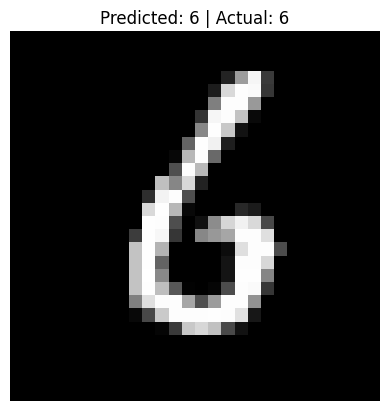

In [17]:
# Pick one image from test set
sample_image, actual_label = test_data[50]

# Add batch dimension
sample_image = sample_image.unsqueeze(0)

# Predict
model.eval()
with torch.no_grad():
    output = model(sample_image)
    predicted = torch.max(output, 1)[1]

plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted.item()} | Actual: {actual_label}")
plt.axis('off')
plt.show()

*   **`sample_image = sample_image.unsqueeze(0)`**:
    *   Your model (`MNISTnet`) was trained to expect inputs in batches (even if a batch contains only one image). The `DataLoader` automatically adds a batch dimension, making the shape `[batch_size, channels, height, width]` (e.g., `[64, 1, 28, 28]`).
    *   When you pick a single image from `test_data`, its shape is typically `[channels, height, width]` (e.g., `[1, 28, 28]`).
    *   `unsqueeze(0)` adds a new dimension at position 0, effectively turning `[1, 28, 28]` into `[1, 1, 28, 28]`. This makes it look like a batch of one image, which the model can then process.

*   **`predicted = torch.max(output, 1)[1]`**: This line extracts the predicted class from the model's output. `torch.max(output, 1)` finds the maximum value along the channel dimension (dimension 1 for the logits of `[1, 10]`) and returns both the maximum value and its index. The index is the predicted digit.

## Why SGD gave you 97.40 vs Adam's 97.13

Surprising right? SGD beat Adam here. This actually happens with well-tuned learning rates on simple datasets like MNIST.
Adam adapts learning rate automatically which helps on complex problems. But on simple problems like MNIST — that adaptation adds noise. SGD with a clean fixed learning rate sometimes generalizes better.
This is a known phenomenon — Adam trains faster but SGD often finds a slightly better final solution given enough epochs.
In research papers you'll often see SGD used for final training even though Adam is used for quick experiments.

## Why accuracy dropped with Dropout

Dropout randomly switches off 30% of neurons during every training batch. So your network is never using its full capacity during training. It's like studying for an exam with one hand tied behind your back deliberately.
This feels like it's making things worse. But it's actually making the network more honest.

## What Dropout actually does

Without Dropout — neurons start depending on each other. Neuron A always relies on Neuron B to correct its mistakes. This is called co-adaptation. Network memorizes training data instead of learning patterns. Works great on training data, fails on new data. That's overfitting.
With Dropout — every neuron knows it might be switched off randomly. So every neuron is forced to learn independently. Network learns more robust features. Generalizes better to new data.